In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [2]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test =pd.read_csv("/kaggle/input/titanic/test.csv")

In [3]:
train_len=len(train)

df=pd.concat([train,test],axis=0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df=df.drop(columns=["Cabin"],axis=1)

In [5]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Fare"] = df["Fare"].fillna(df["Fare"].mean())

In [6]:
df["Embarked"].mode()[0]

'S'

In [7]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [8]:
df["Fare"]=np.log(df["Fare"]+1)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: UserWarning: 



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.



Please adapt your code to use either `displot` (a figure-level function with

similar flexibility) or `histplot` (an axes-level function for histograms).



For a guide to updating your code to use the new functions, please see

https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751



  """Entry point for launching an IPython kernel.


<AxesSubplot:xlabel='Fare', ylabel='Density'>

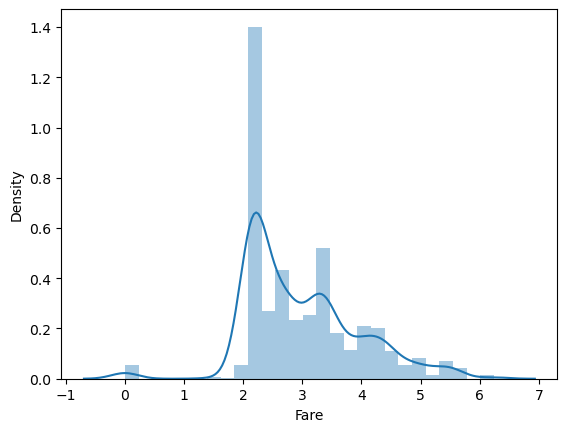

In [9]:
sns.distplot(df["Fare"])

In [10]:
df=df.drop(columns=["Name","Ticket"],axis=1)
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0.0,3,male,22.0,1,0,2.110213,S
1,2,1.0,1,female,38.0,1,0,4.280593,C
2,3,1.0,3,female,26.0,0,0,2.188856,S
3,4,1.0,1,female,35.0,1,0,3.990834,S
4,5,0.0,3,male,35.0,0,0,2.202765,S


In [11]:
from sklearn.preprocessing import LabelEncoder
cols=["Sex","Embarked"]
le=LabelEncoder()

for col in cols:
    df[col] = le.fit_transform(df[col])
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0.0,3,1,22.0,1,0,2.110213,2
1,2,1.0,1,0,38.0,1,0,4.280593,0
2,3,1.0,3,0,26.0,0,0,2.188856,2
3,4,1.0,1,0,35.0,1,0,3.990834,2
4,5,0.0,3,1,35.0,0,0,2.202765,2


In [12]:
train=df.iloc[:train_len, :]
test=df.iloc[train_len:, :]

In [13]:
test.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,NaN,3,1,34.5,0,0,2.178064,1
1,893,NaN,3,0,47.0,1,0,2.079442,2
2,894,NaN,2,1,62.0,0,0,2.369075,1
3,895,NaN,3,1,27.0,0,0,2.268252,2
4,896,NaN,3,0,22.0,1,1,2.586824,2


In [14]:
X=train.drop(columns=["PassengerId","Survived"],axis=1)
y=train["Survived"]

In [15]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,22.0,1,0,2.110213,2
1,1,0,38.0,1,0,4.280593,0
2,3,0,26.0,0,0,2.188856,2
3,1,0,35.0,1,0,3.990834,2
4,3,1,35.0,0,0,2.202765,2


In [16]:
def classify(model):
    x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
    model.fit(x_train,y_train)
    print("Accuracy: ", model.score(x_test,y_test))
    
    score=cross_val_score(model,X,y,cv=5)
    print("CV Score: ",np.mean(score))

In [17]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
classify(model)

Accuracy:  0.7802690582959642

CV Score:  0.8092272926997678


In [18]:
from sklearn.ensemble import ExtraTreesClassifier

model=ExtraTreesClassifier()

classify(model)

Accuracy:  0.7982062780269058

CV Score:  0.7879103634423451


In [19]:
from xgboost import XGBClassifier
model=XGBClassifier()
classify(model)

Accuracy:  0.7892376681614349

CV Score:  0.8125980792166217


In [20]:
from lightgbm import LGBMClassifier
model=LGBMClassifier()
classify(model)

Accuracy:  0.8116591928251121

CV Score:  0.8238277572029377


In [21]:
model=LGBMClassifier()
model.fit(X,y)

LGBMClassifier()

In [22]:
test.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,NaN,3,1,34.5,0,0,2.178064,1
1,893,NaN,3,0,47.0,1,0,2.079442,2
2,894,NaN,2,1,62.0,0,0,2.369075,1
3,895,NaN,3,1,27.0,0,0,2.268252,2
4,896,NaN,3,0,22.0,1,1,2.586824,2


In [23]:
X_test=test.drop(columns=["PassengerId","Survived"],axis=1)


In [24]:
X_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.5,0,0,2.178064,1
1,3,0,47.0,1,0,2.079442,2
2,2,1,62.0,0,0,2.369075,1
3,3,1,27.0,0,0,2.268252,2
4,3,0,22.0,1,1,2.586824,2


In [25]:
pred=model.predict(X_test)
pred

array([0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0.,
       1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0.,
       1., 0., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1.,
       0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 1., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1.,
       1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0.,
       0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1.,
       0., 1., 0., 1., 0.

In [26]:
sub=pd.read_csv("/kaggle/input/titanic/gender_submission.csv")
sub.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [27]:
sub.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 418 entries, 0 to 417

Data columns (total 2 columns):

 #   Column       Non-Null Count  Dtype

---  ------       --------------  -----

 0   PassengerId  418 non-null    int64

 1   Survived     418 non-null    int64

dtypes: int64(2)

memory usage: 6.7 KB


In [28]:
sub["Survived"] = pred
sub["Survived"] = sub["Survived"].astype("int")

In [29]:
sub.info()

<class 'pandas.core.frame.DataFrame'>

RangeIndex: 418 entries, 0 to 417

Data columns (total 2 columns):

 #   Column       Non-Null Count  Dtype

---  ------       --------------  -----

 0   PassengerId  418 non-null    int64

 1   Survived     418 non-null    int64

dtypes: int64(2)

memory usage: 6.7 KB


In [30]:
sub.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


In [31]:
sub.to_csv("submission5.csv",index=False)